# Introduction to Artificial Inteligence

Katarzyna Podwysocka



# Data Analysis



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import pylab as plot
import re
params = { 'axes.labelsize': "medium", 'xtick.labelsize': 'medium', 'legend.fontsize': 20, 'figure.dpi': 200,'figure.figsize': [10, 5]
}
plot.rcParams.update(params)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')


In [5]:
train.head(40)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [6]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
train.shape

(891, 12)

In [8]:
test.shape

(418, 11)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB


In [10]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object
Fare           417 non-null float64
Cabin          91 non-null object
Embarked       418 non-null object
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [11]:
import seaborn as sns
sns.set()

In [12]:
def bar_chart(feature):
    survived = train[train['Survived']==1][feature].value_counts()
    dead = train[train['Survived']==0][feature].value_counts()

In [13]:
def bar_chart(feature):
    survived = train[train['Survived']==1][feature].value_counts()
    dead = train[train['Survived']==0][feature].value_counts()
    df = pd.DataFrame([survived,dead])
    df.index = ['Survived','Dead']
    df.plot(kind='bar',stacked=True, figsize=(10,5))

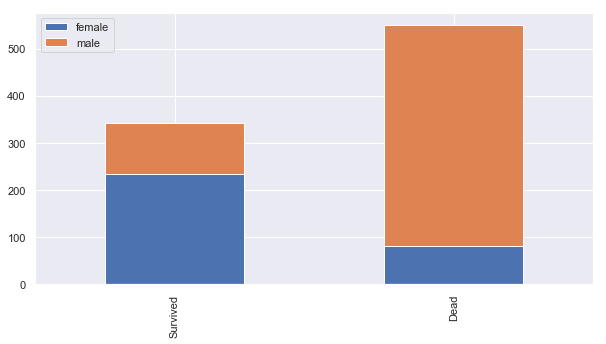

In [14]:
bar_chart('Sex')


In [15]:
train.Sex.value_counts()


male      577
female    314
Name: Sex, dtype: int64

In [16]:
train.groupby('Sex').Survived.value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: Survived, dtype: int64

In [17]:
train[['Sex', 'Survived']].groupby(['Sex'], as_index=False).mean()


,Sex,Survived
0,female,0.742038
1,male,0.188908


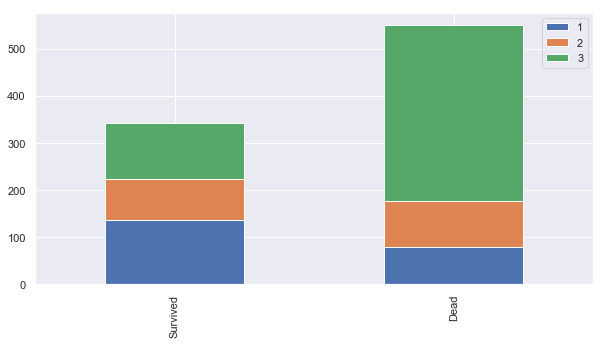

In [18]:
bar_chart('Pclass')

In [19]:
train.Pclass.value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

In [20]:
train.groupby('Pclass').Survived.value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: Survived, dtype: int64

In [21]:
train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


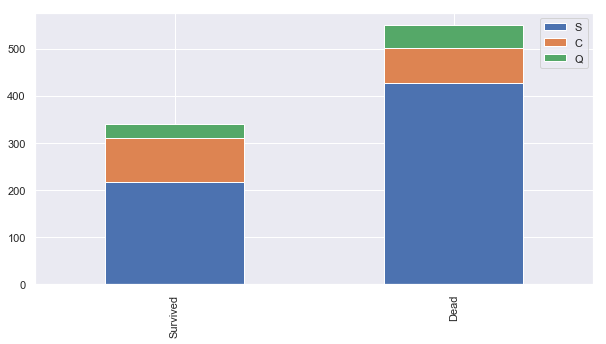

In [22]:
bar_chart('Embarked')

In [23]:
train.Embarked.value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [24]:
train.groupby('Embarked').Survived.value_counts()

Embarked  Survived
C         1            93
          0            75
Q         0            47
          1            30
S         0           427
          1           217
Name: Survived, dtype: int64

In [25]:
train[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


Text(0, 0.5, 'Passangers')

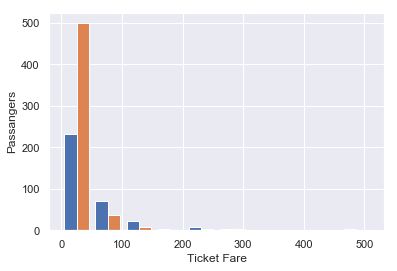

In [26]:
plt.hist([train[train['Survived'] == 1]['Fare'], train[train['Survived'] == 0]['Fare']])
plt.xlabel('Ticket Fare')
plt.ylabel('Passangers')

# Preparing Data for modelling

In [27]:
train_test_data = [train, test] 

for dataset in train_test_data:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.')

In [28]:
train.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs


In [29]:
test['Title'].value_counts()

Mr        240
Miss       78
Mrs        72
Master     21
Rev         2
Col         2
Dona        1
Ms          1
Dr          1
Name: Title, dtype: int64

In [30]:
train['Title'].value_counts(),


(Mr          517
 Miss        182
 Mrs         125
 Master       40
 Dr            7
 Rev           6
 Major         2
 Col           2
 Mlle          2
 Jonkheer      1
 Sir           1
 Capt          1
 Ms            1
 Countess      1
 Lady          1
 Don           1
 Mme           1
 Name: Title, dtype: int64,)

In [31]:
title_mapping = {"Miss": 0, "Mr": 1, "Mrs": 2, "Other": 4}
for dataset in train_test_data:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

In [32]:
train.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1.0
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,1.0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1.0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,0.0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,2.0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,2.0


In [33]:
for dataset in train_test_data:
    dataset['Sex'] = dataset['Sex'].map( {'female': 1, 'male': 0} ).astype(int)

In [34]:
train.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,2.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,2.0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1.0
5,6,0,3,"Moran, Mr. James",0,NaN,0,0,330877,8.4583,NaN,Q,1.0
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,17463,51.8625,E46,S,1.0
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,NaN,S,0.0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,NaN,S,2.0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,NaN,C,2.0


In [35]:
train.Embarked.value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [36]:
for dataset in train_test_data:
    dataset['Embarked'] = dataset['Embarked'].fillna('S')
    dataset['Embarked'] = dataset['Embarked'].map( {'S': 0, 'C': 1, 'Q':2} ).astype(int)

In [37]:
test.head(15)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,2,1.0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,0,2.0
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,2,1.0
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,0,1.0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,0,2.0
5,897,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,0,1.0
6,898,3,"Connolly, Miss. Kate",1,30.0,0,0,330972,7.6292,NaN,2,0.0
7,899,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,0,1.0
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",1,18.0,0,0,2657,7.2292,NaN,1,2.0
9,901,3,"Davies, Mr. John Samuel",0,21.0,2,0,A/4 48871,24.1500,NaN,0,1.0


In [40]:
train['Family'] =  train["Parch"] + train["SibSp"]
train['Family'].loc[train['Family'] > 0] = 1
train['Family'].loc[train['Family'] == 0] = 0

test['Family'] =  test["Parch"] + test["SibSp"]
test['Family'].loc[test['Family'] > 0] = 1
test['Family'].loc[test['Family'] == 0] = 0

In [41]:
test.head(15)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,2,1.0,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,0,2.0,1
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,2,1.0,0
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,0,1.0,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,0,2.0,1
5,897,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,0,1.0,0
6,898,3,"Connolly, Miss. Kate",1,30.0,0,0,330972,7.6292,NaN,2,0.0,0
7,899,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,0,1.0,1
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",1,18.0,0,0,2657,7.2292,NaN,1,2.0,0
9,901,3,"Davies, Mr. John Samuel",0,21.0,2,0,A/4 48871,24.1500,NaN,0,1.0,1


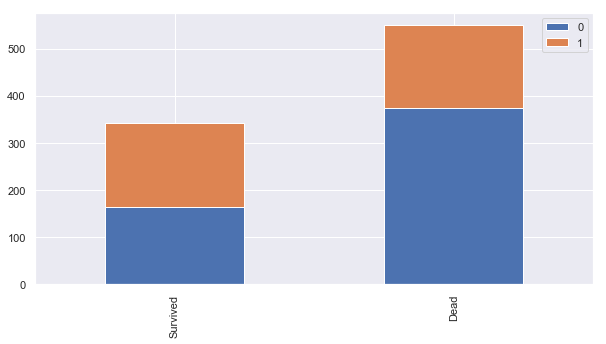

In [42]:
bar_chart('Family')

In [43]:
for dataset in train_test_data:
    dataset.drop('Name', axis=1, inplace=True)
    dataset.drop('Parch', axis=1, inplace=True)
    dataset.drop('SibSp', axis=1, inplace=True)
    dataset.drop('Ticket', axis=1, inplace=True)

In [44]:
train.head(20)

,PassengerId,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,Family
0,1,0,3,0,22.0,7.2500,NaN,0,1.0,1
1,2,1,1,1,38.0,71.2833,C85,1,2.0,1
2,3,1,3,1,26.0,7.9250,NaN,0,0.0,0
3,4,1,1,1,35.0,53.1000,C123,0,2.0,1
4,5,0,3,0,35.0,8.0500,NaN,0,1.0,0
5,6,0,3,0,NaN,8.4583,NaN,2,1.0,0
6,7,0,1,0,54.0,51.8625,E46,0,1.0,0
7,8,0,3,0,2.0,21.0750,NaN,0,0.0,1
8,9,1,3,1,27.0,11.1333,NaN,0,2.0,1
9,10,1,2,1,14.0,30.0708,NaN,1,2.0,1


In [45]:
train["Age"].fillna(train.groupby("Title")["Age"].transform("median"), inplace=True)
test["Age"].fillna(test.groupby("Title")["Age"].transform("median"), inplace=True)

In [46]:
for dataset in train_test_data:
    dataset.loc[ dataset['Age'] <= 18, 'Age'] = 0,
    dataset.loc[(dataset['Age'] > 18) & (dataset['Age'] <= 30), 'Age'] = 1,
    dataset.loc[(dataset['Age'] > 30) & (dataset['Age'] <= 42), 'Age'] = 2,
    dataset.loc[(dataset['Age'] > 42) & (dataset['Age'] <= 65), 'Age'] = 3,
    dataset.loc[ dataset['Age'] > 65, 'Age'] = 4

In [47]:
train.head(15)

,PassengerId,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,Family
0,1,0,3,0,1.0,7.2500,NaN,0,1.0,1
1,2,1,1,1,2.0,71.2833,C85,1,2.0,1
2,3,1,3,1,1.0,7.9250,NaN,0,0.0,0
3,4,1,1,1,2.0,53.1000,C123,0,2.0,1
4,5,0,3,0,2.0,8.0500,NaN,0,1.0,0
5,6,0,3,0,1.0,8.4583,NaN,2,1.0,0
6,7,0,1,0,3.0,51.8625,E46,0,1.0,0
7,8,0,3,0,0.0,21.0750,NaN,0,0.0,1
8,9,1,3,1,1.0,11.1333,NaN,0,2.0,1
9,10,1,2,1,0.0,30.0708,NaN,1,2.0,1


In [48]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Sex            418 non-null int32
Age            418 non-null float64
Fare           417 non-null float64
Cabin          91 non-null object
Embarked       418 non-null int32
Title          418 non-null float64
Family         418 non-null int64
dtypes: float64(3), int32(2), int64(3), object(1)
memory usage: 26.2+ KB


In [49]:
train["Fare"].fillna(train.groupby("Pclass")["Fare"].transform("median"), inplace=True)
test["Fare"].fillna(test.groupby("Pclass")["Fare"].transform("median"), inplace=True)

In [50]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Sex            418 non-null int32
Age            418 non-null float64
Fare           418 non-null float64
Cabin          91 non-null object
Embarked       418 non-null int32
Title          418 non-null float64
Family         418 non-null int64
dtypes: float64(3), int32(2), int64(3), object(1)
memory usage: 26.2+ KB


In [51]:
train.Cabin.value_counts()

B96 B98            4
G6                 4
C23 C25 C27        4
F2                 3
E101               3
D                  3
C22 C26            3
F33                3
B18                2
D35                2
C78                2
D26                2
B49                2
D17                2
E25                2
C2                 2
E121               2
B35                2
E44                2
C93                2
B57 B59 B63 B66    2
C65                2
B51 B53 B55        2
C125               2
C83                2
E33                2
C52                2
D20                2
C68                2
E24                2
                  ..
E46                1
T                  1
B71                1
D30                1
E12                1
C118               1
B82 B84            1
B30                1
A5                 1
C128               1
A34                1
B19                1
C90                1
F38                1
E17                1
C46                1
A36          

In [52]:
pd.crosstab(train['Pclass'], train['Cabin'])

Cabin,A10,A14,A16,A19,A20,A23,A24,A26,A31,A32,...,E8,F E69,F G63,F G73,F2,F33,F38,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,1,1,1,1,...,2,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,3,0,2,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,2,0,0,1,0,4,0


In [53]:
cabin_mapping = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6, "T": 7}
for dataset in train_test_data:
    dataset['Cabin'] = dataset['Cabin'].map(cabin_mapping)
    dataset['Cabin'] = dataset['Cabin'].fillna(0)

In [54]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Sex            891 non-null int32
Age            891 non-null float64
Fare           891 non-null float64
Cabin          891 non-null float64
Embarked       891 non-null int32
Title          891 non-null float64
Family         891 non-null int64
dtypes: float64(4), int32(2), int64(4)
memory usage: 62.7 KB


In [55]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Sex            418 non-null int32
Age            418 non-null float64
Fare           418 non-null float64
Cabin          418 non-null float64
Embarked       418 non-null int32
Title          418 non-null float64
Family         418 non-null int64
dtypes: float64(4), int32(2), int64(3)
memory usage: 26.2 KB


In [56]:
dataset.head(20)

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,Family
0,892,3,0,2.0,7.8292,0.0,2,1.0,0
1,893,3,1,3.0,7.0000,0.0,0,2.0,1
2,894,2,0,3.0,9.6875,0.0,2,1.0,0
3,895,3,0,1.0,8.6625,0.0,0,1.0,0
4,896,3,1,1.0,12.2875,0.0,0,2.0,1
5,897,3,0,0.0,9.2250,0.0,0,1.0,0
6,898,3,1,1.0,7.6292,0.0,2,0.0,0
7,899,2,0,1.0,29.0000,0.0,0,1.0,1
8,900,3,1,0.0,7.2292,0.0,1,2.0,0
9,901,3,0,1.0,24.1500,0.0,0,1.0,1


# Modelling

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
k_fold = KFold(n_splits=10, shuffle=True, random_state=0)

In [58]:
x = train.drop('Survived', 1)
y = train['Survived']

RANDOM FOREST CLASSIFIER

In [69]:
a = RandomForestClassifier(n_estimators=13)
scoring = 'accuracy'
score = cross_val_score(a, x, y, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.82222222 0.80898876 0.74157303 0.78651685 0.79775281 0.85393258
 0.84269663 0.79775281 0.76404494 0.83146067]


In [72]:
print (str(round(np.mean(score)*100, 2)) + ' % accuracy')

80.47 % accuracy


In [61]:
titanic = pd.DataFrame({ "PassengerId": test["PassengerId"], "Survived": y })
titanic.to_csv('titanic.csv', index=False)

In [137]:
titanic.head(15)

,PassengerId,Survived
0,892.0,0
1,893.0,1
2,894.0,1
3,895.0,1
4,896.0,0
5,897.0,0
6,898.0,0
7,899.0,0
8,900.0,1
9,901.0,1


In [ ]:
References:
   1.https://software.intel.com/en-us/ai/courses/machine-learning  
   2.https://www.kaggle.com/sinakhorami/titanic-best-working-classifier 
    